# Эмбеддинги для текста

## Импорт библиотек, установка констант

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [ ]:
AG_NEWS_TRAIN = 'https://www.dropbox.com/scl/fi/ok9tt9prs7yl9o974ipgn/ag_news_train.csv?rlkey=wlh19mk7q5cn3v6n7zluzx2bn&st=y5i93t3v&dl=1'
AG_NEWS_TEST = 'https://www.dropbox.com/scl/fi/5abmk0nnzz4tqyajqhfwu/ag_news_test.csv?rlkey=yu4ngbm1yccvvcgs1u0htpav4&st=3cv3suy2&dl=1'

## Загрузка данных

In [ ]:
data_train = pd.read_csv(AG_NEWS_TRAIN, sep='\t')
data_test = pd.read_csv(AG_NEWS_TEST, sep='\t')

In [ ]:
labels_train = data_train['label']
labels_test = data_test['label']

In [ ]:
len(labels_train)

120000

## Обзор данных

Посмотрим на распределение классов.

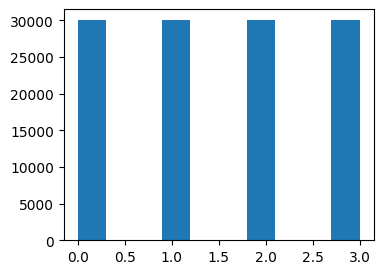

In [ ]:
plt.figure(figsize=(4, 3))
plt.hist(labels_train);

И на облако слов.

In [ ]:
from wordcloud import WordCloud

def create_cloud_graph(corpus):
    wordcloud = WordCloud(
        width=1600, height=800, max_words=200, background_color='white', collocations=False
    ).generate(' '.join(corpus))

    plt.figure(figsize=(20,10))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show();

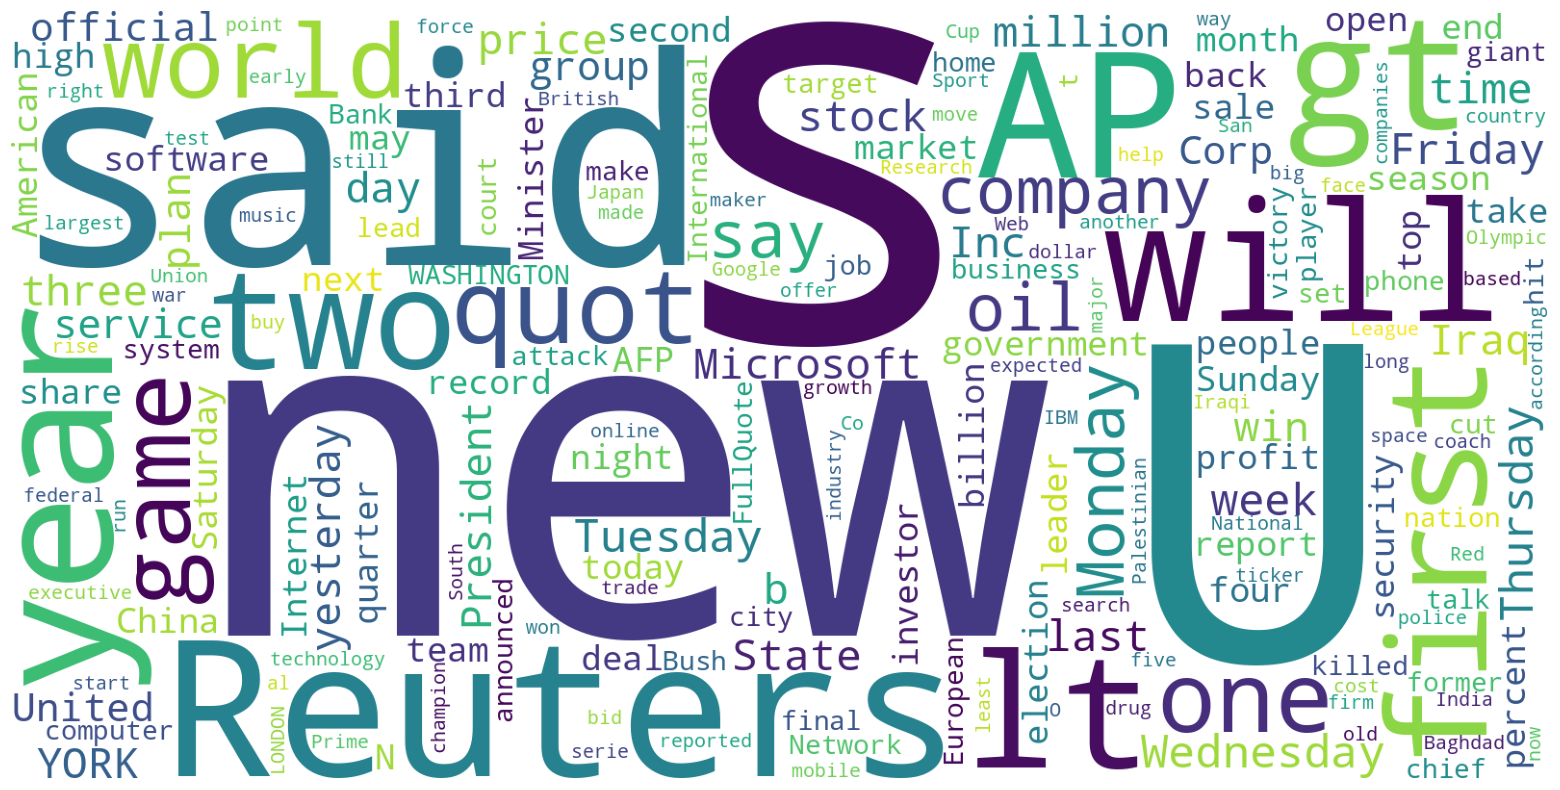

In [ ]:
create_cloud_graph(data_train['text'])

## Bag of Words

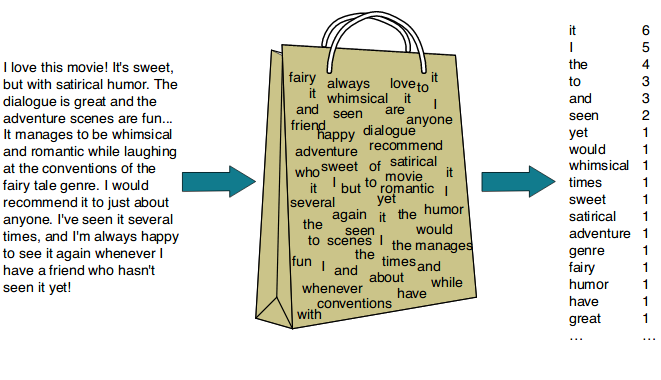


$$x_{i} = \sum_{v \in d} [v = v_i],$$

где $x_{i}$ – элемент итогового вектора, $d$ – документ, $v$ – слово. Размер вектора $x$ равер размеру словаря.

Перед тем, как рассматривать алгоритмы классификации, нужно разобраться с тем, как мы будем подавать наши тексты на вход разным алгоритмам. Все они работают с числами, и текст, соответственно, тоже нужно превратить в число. А точнее в набор чисел - вектор.

Самый простой способ векторного представления текста называется "мешком слов" (bag-of-words). Мешок тут не какой-то технический термин, а метафора. В таком способе векторизации никак не учитывается порядок. Слова как бы складываются в "мешок" и перемешиваются.

Если более формально, то для того, чтобы векторизовать некоторый набор документов (=текстов) мешком слов нужно:  
а) составить словарь всех уникальных слов, встречаемых в этих документах  
б) зафиксировать порядок слов в словаре и сопоставить каждому из них порядковый индекс  
в) составить для каждого документа вектор размерности

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
bow_vectorizer = CountVectorizer(min_df=1)
bow_vectorizer.fit(data_train['text']);

In [ ]:
bow_vector = bow_vectorizer.transform(data_train['text'][:1])
bow_vector.shape

(1, 65006)

Уменьшим размер словаря, выбросив редкие слова и слишком частые.

In [ ]:
bow_vectorizer = CountVectorizer(min_df=4, max_df=0.95)
bow_vectorizer.fit(data_train['text']);

In [ ]:
bow_vector = bow_vectorizer.transform(data_train['text'][:1])
bow_vector.shape

(1, 29350)

## Обучение модели

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
def train_eval_model(train_X, test_X, train_y, test_y):
    model = LogisticRegression(max_iter=500)
    model.fit(train_X, train_y)

    train_pred = model.predict(train_X)
    test_pred = model.predict(test_X)

    train_acc = accuracy_score(train_y, train_pred)
    test_acc = accuracy_score(test_y, test_pred)

    print('Train accuracy:', round(train_acc, 3))
    print('Test accuracy: ', round(test_acc, 3))

In [ ]:
bow_train = bow_vectorizer.transform(data_train['text'])
bow_test = bow_vectorizer.transform(data_test['text'])

In [ ]:
train_eval_model(bow_train, bow_test, labels_train, labels_test)

Train accuracy: 0.978
Test accuracy:  0.909


## TF-IDF

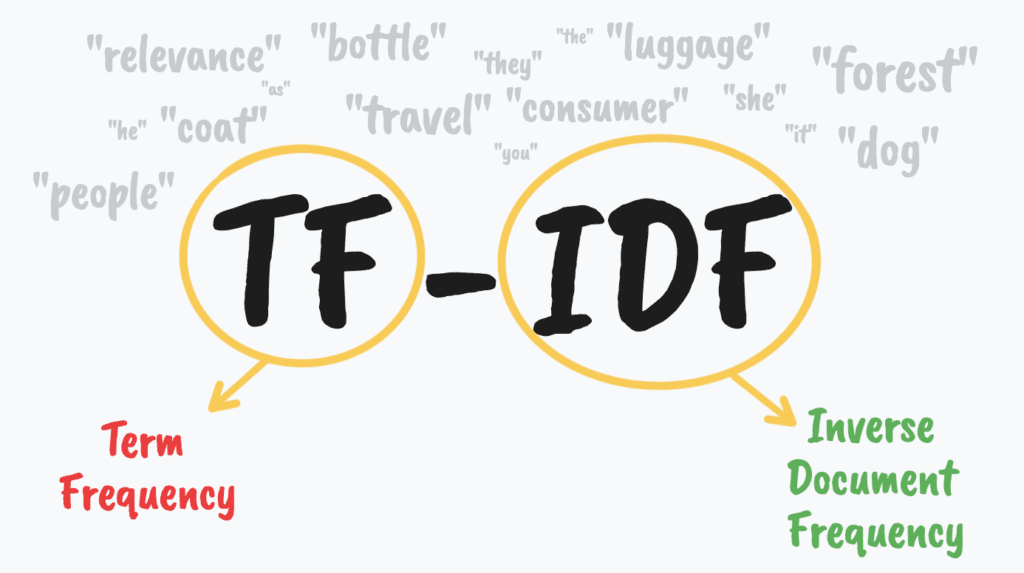

1. __Term frequency__:
$$\text{tf}(t, d) = \frac{N(t, d)}{\sum_{k \in V} N(k, d)},$$
где $N(t, d)$ — количество вхождений слова $t$ в текст $d$.


2. __Inverse Document Frequency__
$$\text{idf}(t, D) = \log \frac{|D|}{|\{d \in D | t \in d\}|},$$

где $\left| \{d\in D: t \in d\} \right|$ – количество текстов в коллекции, содержащих слово $t$.


$$\text{tf-idf}(t,d, D) = \text{tf}(t, d)\cdot \text{idf}(t, D).$$

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf_vectorizer = TfidfVectorizer(min_df=4, max_df=0.95)
tfidf_vectorizer.fit(data_train['text']);

In [ ]:
tfidf_train = tfidf_vectorizer.transform(data_train['text'])
tfidf_test = tfidf_vectorizer.transform(data_test['text'])

In [ ]:
train_eval_model(tfidf_train, tfidf_test, labels_train, labels_test)

Train accuracy: 0.94
Test accuracy:  0.918


## Визуализация эмбеддингов текстов



Для визуализации понизим размерность с помощью `t-SNE`.

In [ ]:
from sklearn.manifold import TSNE

tsne_vectors = TSNE(
    n_components=2, learning_rate='auto', init='random', perplexity=30
).fit_transform(tfidf_train[-2000:])

tsne_vectors.shape

(2000, 2)

In [ ]:
colors = labels_train[-2000:]
classes = ['World', 'Sports', 'Business', 'Sci/Tech']

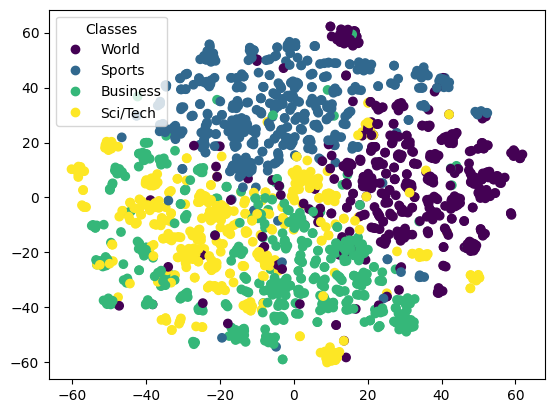

In [ ]:
scatter = plt.scatter(tsne_vectors[:, 0], tsne_vectors[:, 1], c=colors)

plt.legend(scatter.legend_elements()[0], classes, title="Classes");

## Поиск похожих текстов

In [ ]:
texts = data_train['text'][:1000]
text_embeddings = tfidf_train[:1000].toarray()

In [ ]:
def cosine(embedding, other_embeddings):
    normed_embeddings = other_embeddings.T / np.linalg.norm(other_embeddings, axis=1)
    return embedding @ normed_embeddings

def find_nearest(query, k=10):
    embedding = tfidf_vectorizer.transform([query])
    similarities = cosine(embedding, text_embeddings)[0]
    nearest_idxs = np.argsort(similarities)[-k:][::-1]

    return list(texts[nearest_idxs])

In [ ]:
nearest = find_nearest(query="Bill Gates is the head of Microsoft", k=5)
for text in nearest:
    print(text)
    print()

Microsoft Says Battle in Japan Hurting Image By YURI KAGEYAMA     TOKYO (AP) -- The head of Microsoft Corp. (MSFT)'s Japan unit acknowledged Tuesday that the U.S...

Microsoft Corp. 2.0: a kinder corporate culture Even a genius can mess up. Bill Gates was a brilliant technologist when he cofounded Microsoft , but as he guided it to greatness in both size and historical consequence, he blundered. He terrorized underlings with his temper and parceled out praise like Scrooge gave to charity. Only the lash inspired the necessary aggressiveness to beat the competition, he thought.

Entertainment World Wary of Microsoft (AP) AP - CinemaNow Inc., the Internet-based movie service, is a rarity in Hollywood  #151; a company that eagerly embraces Microsoft Corp. technology and relies on it exclusively to transmit, protect and display the movies it rents to customers. Then again, Microsoft is a major investor in the company, which is also owned by independent studio Lions Gate.

Taking the Microso

## Резюме

1. Узнали, как применять Bag of Words и TF-IDF для классификации текста
2. А также как визуализировать полученные эмбеддинги